In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# =====================================================
# Read files
# =====================================================
with open("c:\Users\MY-PC\Downloads\result_practice.txt", "r") as f:
    practice_text = f.read()

with open("c:\Users\MY-PC\Downloads\result_theory.txt", "r") as f:
    theory_text = f.read()

# =====================================================
# Parse files
# =====================================================
practice_pattern = re.compile(
    r"q = ([0-9.]+)\s+and r = ([0-9.]+), min error gamma is ([0-9.]+)"
)

theory_pattern = re.compile(
    r"\(q, r\)\s*=\s*\(([0-9.]+),\s*([0-9.]+)\):\s*([0-9.]+)"
)

practice = [
    (float(q), float(r), float(g))
    for q, r, g in practice_pattern.findall(practice_text)
]

theory = [
    (float(q), float(r), float(g))
    for q, r, g in theory_pattern.findall(theory_text)
]

df_pr = pd.DataFrame(practice, columns=["q", "r", "gamma"])
df_th = pd.DataFrame(theory, columns=["q", "r", "gamma"])

# =====================================================
# Pivot tables
# =====================================================
pivot_pr = df_pr.pivot(index="r", columns="q", values="gamma")
pivot_th = df_th.pivot(index="r", columns="q", values="gamma")

# Shared color scale
vmin = min(df_pr.gamma.min(), df_th.gamma.min())
vmax = max(df_pr.gamma.max(), df_th.gamma.max())

# =====================================================
# Figure 1: Practice heatmap
# =====================================================
fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(
    pivot_pr.values,
    origin="lower",
    aspect="auto",
    extent=[
        pivot_pr.columns.min(),
        pivot_pr.columns.max(),
        pivot_pr.index.min(),
        pivot_pr.index.max(),
    ],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

ax.set_xlabel("q")
ax.set_ylabel("r")
ax.set_title("Practice: Optimal gamma")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Optimal gamma")

plt.tight_layout()
plt.savefig("practice_heatmap.png", dpi=300)

# =====================================================
# Figure 2: Theory heatmap
# =====================================================
fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(
    pivot_th.values,
    origin="lower",
    aspect="auto",
    extent=[
        pivot_th.columns.min(),
        pivot_th.columns.max(),
        pivot_th.index.min(),
        pivot_th.index.max(),
    ],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

ax.set_xlabel("q")
ax.set_ylabel("r")
ax.set_title("Theory: Optimal gamma")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Optimal gamma")

plt.tight_layout()
plt.savefig("theory_heatmap.png", dpi=300)

# =====================================================
# Figure 3: Line comparison
# =====================================================
fig, ax = plt.subplots(figsize=(10,7))

qs = sorted(df_th.q.unique())

cmap = plt.cm.viridis
norm = Normalize(vmin=min(qs), vmax=max(qs))

for q in qs:

    theory_curve = (
        df_th[df_th.q == q]
        .sort_values("r")
    )

    practice_curve = (
        df_pr[df_pr.q == q]
        .sort_values("r")
    )

    color = cmap(norm(q))

    ax.plot(
        theory_curve.r,
        theory_curve.gamma,
        color=color,
        linewidth=2,
    )

    ax.plot(
        practice_curve.r,
        practice_curve.gamma,
        color=color,
        linestyle="--",
        linewidth=2,
    )

ax.set_xlabel("r")
ax.set_ylabel("Optimal gamma")
ax.set_yscale("log")
ax.grid(alpha=0.3)

legend = [
    Line2D([0], [0], color="black", lw=2, label="Theory"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Practice"),
]

ax.legend(handles=legend, title="Dataset")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("q")

plt.tight_layout()
plt.savefig("gamma_line_comparison.png", dpi=300)

plt.show()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3530343292.py, line 10)

In [5]:
import os
import re
import pickle
import numpy as np

# ==========================
# User settings
# ==========================
directory = "C:\\Users\\MY-PC\\Downloads\\qr-results-900\\results"   # <-- Change this
tau = 0.05                           # Tau to extract
q_list = [0.01000000, 0.17896552, 0.34793103, 0.51689655, 0.68586207, 0.85482759]

# Gamma values used when generating the data
gammas = np.geomspace(0.2, 20, 30)

# Output file
output_file = "c:\\Users\\MY-PC\\Downloads\\results_server\\Results_practice_005.txt"

# Regex to read q and r from filenames like:
# result_q_0.01000000_r_0.01000000.pkl
pattern = re.compile(r"result_q_([0-9.eE+-]+)_r_([0-9.eE+-]+)\.pkl")
print(pattern)
# Collect results grouped by r
results = {}

for filename in sorted(os.listdir(directory)):
    match = pattern.match(filename)
    #print(match)
    if match is None:
        continue

    q = float(match.group(1))
    r = float(match.group(2))
    #print(q)
    #print(r)

    # Only keep selected q values
    if not any(np.isclose(q, q0) for q0 in q_list):
        continue

    print(q)
    filepath = os.path.join(directory, filename)
    
    with open(filepath, "rb") as f:
        data = pickle.load(f)

    tau_dict = data["results_by_tau"]

    # Find the requested tau
    tau_key = None
    for t in tau_dict:
        if np.isclose(float(t), tau):
            tau_key = t
            break

    if tau_key is None:
        continue

    gamma_errors = np.asarray(tau_dict[tau_key]["gamma_errors"])

    # Gamma giving minimum error
    best_gamma = gammas[np.argmin(gamma_errors)]
    # print(f"Best Gamma = {best_gamma}, for r = {r}")

    results.setdefault(r, []).append((q, best_gamma))
print(results)
# Write output
with open(output_file, "w") as f:
    for r in sorted(results):
        # Sort by q
        results[r].sort(key=lambda x: x[0])

        for q, gamma in results[r]:
            f.write(
                f"For tau = {tau:.2f}, q = {q:.2f} and r = {r:.2f}, "
                f"min error gamma is {gamma:.2f}\n"
            )

        f.write("\n")

print(f"Saved results to '{output_file}'")

re.compile('result_q_([0-9.eE+-]+)_r_([0-9.eE+-]+)\\.pkl')
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.17896552
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.34793103
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655
0.51689655

Running numerical optimization over 30x30 grid...
Optimal gamma for (q, r) = (0.01, 0.01): 0.23
Optimal gamma for (q, r) = (0.01, 0.04): 0.30
Optimal gamma for (q, r) = (0.01, 0.08): 0.33
Optimal gamma for (q, r) = (0.01, 0.11): 0.33
Optimal gamma for (q, r) = (0.01, 0.15): 0.33
Optimal gamma for (q, r) = (0.01, 0.18): 0.33
Optimal gamma for (q, r) = (0.01, 0.21): 0.33
Optimal gamma for (q, r) = (0.01, 0.25): 0.32
Optimal gamma for (q, r) = (0.01, 0.28): 0.32
Optimal gamma for (q, r) = (0.01, 0.31): 0.32
Optimal gamma for (q, r) = (0.01, 0.35): 0.32
Optimal gamma for (q, r) = (0.01, 0.38): 0.32
Optimal gamma for (q, r) = (0.01, 0.42): 0.32
Optimal gamma for (q, r) = (0.01, 0.45): 0.32
Optimal gamma for (q, r) = (0.01, 0.48): 0.32
Optimal gamma for (q, r) = (0.01, 0.52): 0.32
Optimal gamma for (q, r) = (0.01, 0.55): 0.32
Optimal gamma for (q, r) = (0.01, 0.58): 0.32
Optimal gamma for (q, r) = (0.01, 0.62): 0.32
Optimal gamma for (q, r) = (0.01, 0.65): 0.32
Optimal gamma for (q, r) = (0.

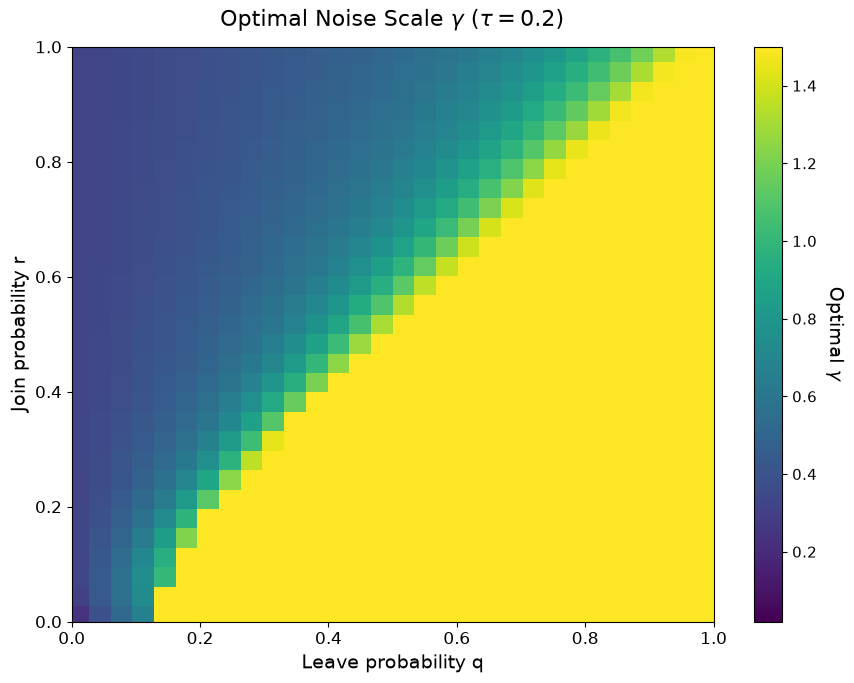

Optimization complete. Heatmap saved as 'optimal_gamma_heatmap.png'.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import norm
from scipy.optimize import minimize_scalar

# --- Plot Aesthetics ---
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "image.cmap": "magma",
    "axes.grid": False
})

# --- System Constants ---
N0 = 1000.0         # Initial Population
T = 100              # Finite Time Horizon
d = 12.0            # Dimension of Data
tr_sigma_inv = d    # Trace(Sigma^-1) is exactly d for an identity covariance matrix
tau = 0.01          # Privacy Threshold (Matched to experiment)
R = 10.0             # Clipping Radius

# --- Vectorized Monte Carlo Integration ---
# By generating fixed samples once, the MC expectation is completely deterministic
# as a function of gamma, allowing SciPy's optimizer to compute gradients cleanly.
np.random.seed(42)
NUM_SAMPLES = 500_000

# For a multivariate standard normal z ~ N(0, I_d), the squared L2-norm ||z||^2
# strictly follows a Chi-Square distribution with d degrees of freedom.
# We take the square root to get the exact L2-norms ||z|| for the theoretical integral.
z_norms = np.sqrt(np.random.chisquare(df=d, size=NUM_SAMPLES))
z_bar = np.minimum(z_norms, R)

# Filter out values dangerously close to 0 to prevent division by zero
valid_mask = z_bar > 1e-9
z_bar_valid = z_bar[valid_mask]

def p_tau_mc(gamma):
    """Computes the marginal leakage probability via Monte Carlo expectation."""
    term1 = (tau * np.sqrt(N0) * gamma) / z_bar_valid
    term2 = z_bar_valid / (2 * np.sqrt(N0) * gamma)

    # 1 - Phi(...)
    L_z = 1.0 - norm.cdf(term1 - term2)

    # Return the expected value over the dataset
    return np.sum(L_z) / NUM_SAMPLES

# --- Objective Function ---
def cumulative_error(gamma, q, r):
    """The finite-horizon closed-form objective to be minimized."""
    # 1. Compute expected performative growth factor
    p_t = p_tau_mc(gamma)
    C_gamma = 1.0 + r - (q + r) * p_t

    # Numerator: Mechanism Variance + Intrinsic Variance
    num = (gamma**2 * tr_sigma_inv) + d

    # If C(gamma) is extremely close to 1, use L'Hopital's limit (T * num / N0)
    # to avoid division by zero
    if abs(C_gamma - 1.0) < 1e-6:
        return (num * T) / N0

    # Finite Geometric Series Formula
    denom = N0 * (C_gamma - 1.0)
    geometric_factor = 1.0 - (1.0 / (C_gamma**T))

    # If population collapses exponentially, the error explodes to infinity
    if C_gamma < 1.0:
        # Penalize heavily if the population shrinks, as the error blows up
        return (num / denom) * geometric_factor

    return (num / denom) * geometric_factor

# --- Grid Search for the Heatmap ---
GRID_RESOLUTION = 30
q_values = np.linspace(0.01, 0.99, GRID_RESOLUTION)  # Purge Probability
r_values = np.linspace(0.01, 0.99, GRID_RESOLUTION)  # Reproduction Probability

# Matrix to store the optimal gamma for each (q, r) pair
optimal_gammas = np.zeros((GRID_RESOLUTION, GRID_RESOLUTION))

print(f"Running numerical optimization over {GRID_RESOLUTION}x{GRID_RESOLUTION} grid...")

for i, q in enumerate(q_values):
    for j, r in enumerate(r_values):

        # Optimize gamma strictly within the experimental search bounds
        res = minimize_scalar(
            cumulative_error,
            bounds=(0.02, 20.0),
            args=(q, r),
            method='bounded'
        )

        optimal_gammas[i, j] = res.x
        print(f"Optimal gamma for (q, r) = ({q:.2f}, {r:.2f}): {res.x:.2f}")

# --- Plotting the Heatmap ---
plt.figure(figsize=(9, 7))

# Create the heatmap using the raw values, bounded exactly to the experimental grid
heatmap = plt.pcolormesh(
    q_values, r_values, optimal_gammas.T,
    shading='nearest',
    cmap='viridis',
    vmin=0.02,
    vmax=1.5
)

# Aesthetics and Labels matching the requested style
cbar = plt.colorbar(heatmap)
cbar.set_label(r'Optimal $\gamma$', rotation=270, labelpad=20, fontsize=14)
cbar.ax.tick_params(labelsize=11)

plt.title(r'Optimal Noise Scale $\gamma$ ($\tau = 0.2$)', fontsize=16, pad=15)
plt.xlabel("Leave probability q", fontsize=14)
plt.ylabel("Join probability r", fontsize=14)

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)

plt.tight_layout()
plt.savefig("optimal_gamma_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Optimization complete. Heatmap saved as 'optimal_gamma_heatmap.png'.")

Generating Monte Carlo samples for theory...
Found 900 result files.
Processing result_q_0.01000000_r_0.01000000.pkl


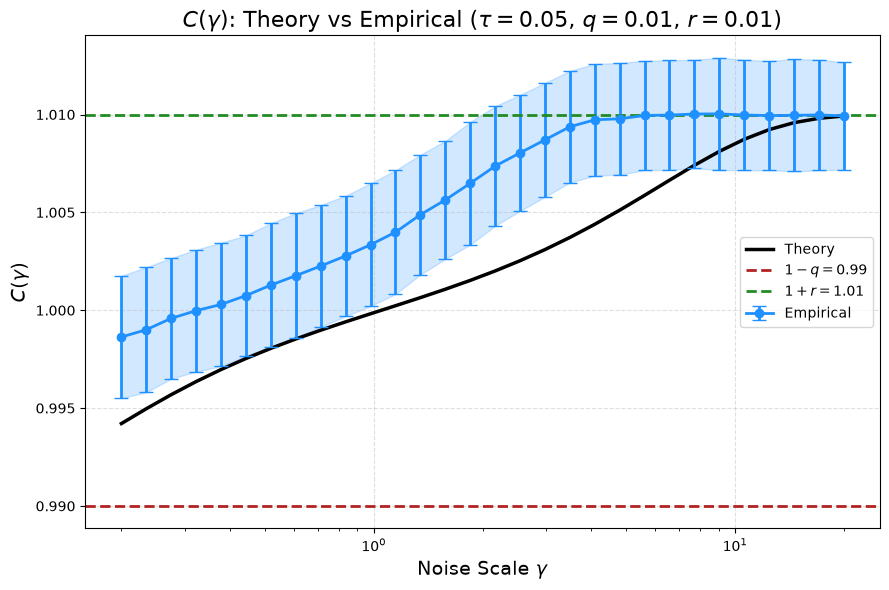

Processing result_q_0.01000000_r_0.04379310.pkl


KeyboardInterrupt: 

In [5]:
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================================
# Fixed parameters (same as theory code)
# ==========================================================

d = 12
N_t_1 = 100
R = 5.0
num_samples = 200000

# Directory containing all pickle files
RESULT_DIR = "C:\\Users\\MY-PC\\Downloads\\qr-results-900\\results"      # <-- Change this

# ==========================================================
# Monte-Carlo samples for theoretical curve
# ==========================================================

print("Generating Monte Carlo samples for theory...")

Z = np.random.randn(num_samples, d)
Z = np.clip(Z, -R, R)

z_norms = np.linalg.norm(Z, axis=1)
z_norms = np.maximum(z_norms, 1e-8)


# ==========================================================
# Theory
# ==========================================================

def compute_p_tau(tau, gamma):

    A = np.sqrt(N_t_1) * gamma

    term1 = tau * A / z_norms
    term2 = z_norms / (2 * A)

    return np.mean(1 - norm.cdf(term1 - term2))


def compute_C_theory(gammas, tau, q, r):

    C = []

    for g in gammas:
        p = compute_p_tau(tau, g)
        C.append(1 + r - (q + r) * p)

    return np.asarray(C)


# ==========================================================
# Iterate through every pickle
# ==========================================================

files = sorted(glob.glob(os.path.join(RESULT_DIR, "*.pkl")))

print(f"Found {len(files)} result files.")

for file in files:

    print(f"Processing {os.path.basename(file)}")

    with open(file, "rb") as f:
        results = pickle.load(f)

    q = results["q"]
    r = results["r"]

    gamma_values = np.geomspace(0.2,20,30)

    # ------------------------------------------------------
    # Each pickle may contain multiple tau values
    # ------------------------------------------------------

    for tau, tau_results in results["results_by_tau"].items():

        empirical_C = np.asarray(
            tau_results["empirical_C_gammas"]
        )

        empirical_std = np.asarray(
            tau_results["empirical_C_std_gammas"]
        )

        theory_C = compute_C_theory(
            gamma_values,
            tau,
            q,
            r
        )

        # ==================================================
        # Plot
        # ==================================================

        plt.figure(figsize=(9,6))

        # Theory
        plt.plot(
            gamma_values,
            theory_C,
            color="black",
            lw=2.5,
            label="Theory"
        )

        # Empirical with error bars
        plt.errorbar(
            gamma_values,
            empirical_C,
            yerr=empirical_std,
            fmt='o-',
            color='dodgerblue',
            linewidth=2,
            capsize=5,
            label='Empirical'
        )

        # Optional shaded band
        plt.fill_between(
            gamma_values,
            empirical_C - empirical_std,
            empirical_C + empirical_std,
            color='dodgerblue',
            alpha=0.20
        )

        # Bounds
        plt.axhline(
            1-q,
            color='firebrick',
            linestyle='--',
            linewidth=2,
            label=rf'$1-q={1-q:.2f}$'
        )

        plt.axhline(
            1+r,
            color='forestgreen',
            linestyle='--',
            linewidth=2,
            label=rf'$1+r={1+r:.2f}$'
        )

        plt.xscale("log")

        plt.xlabel(r"Noise Scale $\gamma$", fontsize=14)
        plt.ylabel(r"$C(\gamma)$", fontsize=14)

        plt.title(
            rf"$C(\gamma)$: Theory vs Empirical ($\tau={tau}$, $q={q}$, $r={r}$)",
            fontsize=16
        )

        plt.grid(True, linestyle='--', alpha=0.4)
        plt.legend()

        plt.tight_layout()
        plt.show()

In [1]:
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================================
# Fixed parameters
# ==========================================================

d = 12
N_t_1 = 1000
R = 10.0
num_samples = 200000

RESULT_DIR = "C:\\Users\\MY-PC\\Downloads\\qr-results-900\\results"          # Folder containing .pkl files
SAVE_DIR = "C:\\Users\\MY-PC\\Downloads\\qr-results-900\\plots"   # Folder to save figures

os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================================
# Monte Carlo samples for theoretical curve
# ==========================================================

print("Generating Monte Carlo samples for theory...")

Z = np.random.randn(num_samples, d)
Z = np.clip(Z, -R, R)

z_norms = np.linalg.norm(Z, axis=1)
z_norms = np.maximum(z_norms, 1e-8)

# ==========================================================
# Theory
# ==========================================================

def compute_p_tau(tau, gamma):
    A = np.sqrt(N_t_1) * gamma
    term1 = (tau * A) / z_norms
    term2 = z_norms / (2 * A)
    return np.mean(1 - norm.cdf(term1 - term2))


def compute_C_theory(gammas, tau, q, r):
    return np.array([
        1 + r - (q + r) * compute_p_tau(tau, g)
        for g in gammas
    ])

# ==========================================================
# Process all pickle files
# ==========================================================

files = sorted(glob.glob(os.path.join(RESULT_DIR, "*.pkl")))

print(f"Found {len(files)} pickle files.")

for file in files:

    with open(file, "rb") as f:
        results = pickle.load(f)

    q = results["q"]
    r = results["r"]

    gamma_values = np.geomspace(0.2,20,30)

    for tau, tau_results in results["results_by_tau"].items():

        empirical_C = np.asarray(
            tau_results["empirical_C_gammas"]
        )

        empirical_std = np.asarray(
            tau_results["empirical_C_std_gammas"]
        )

        theory_C = compute_C_theory(
            gamma_values,
            tau,
            q,
            r
        )

        fig, ax = plt.subplots(figsize=(9,6))

        # Theory
        ax.plot(
            gamma_values,
            theory_C,
            color="black",
            linewidth=2.5,
            label="Theory"
        )

        # Empirical
        ax.errorbar(
            gamma_values,
            empirical_C,
            yerr=empirical_std,
            fmt='o-',
            color='dodgerblue',
            linewidth=2,
            capsize=4,
            label="Empirical"
        )

        # Shaded ±1σ band
        ax.fill_between(
            gamma_values,
            empirical_C - empirical_std,
            empirical_C + empirical_std,
            color="dodgerblue",
            alpha=0.2
        )

        # Bounds
        ax.axhline(
            1-q,
            color="firebrick",
            linestyle="--",
            linewidth=2,
            label=rf"$1-q={1-q:.2f}$"
        )

        ax.axhline(
            1+r,
            color="forestgreen",
            linestyle="--",
            linewidth=2,
            label=rf"$1+r={1+r:.2f}$"
        )

        ax.set_xscale("log")
        ax.set_xlabel(r"Noise Scale $\gamma$")
        ax.set_ylabel(r"$C(\gamma)$")
        ax.set_title(
            rf"$C(\gamma)$: Theory vs Empirical "
            rf"($\tau={tau:.2f}$, $q={q:.2f}$, $r={r:.2f}$)"
        )
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()

        fig.tight_layout()

        # Save figure
        outfile = os.path.join(
            SAVE_DIR,
            f"comparison_q_{q:.2f}_r_{r:.2f}_tau_{tau:.2f}.png"
        )

        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Saved: {outfile}")

print(f"\nAll figures saved to '{SAVE_DIR}'.")

Generating Monte Carlo samples for theory...
Found 900 pickle files.
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.01_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.04_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.08_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.11_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.15_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.18_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.21_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.25_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.28_tau_0.05.png
Saved: C:\Users\MY-PC\Downloads\qr-results-900\plots\comparison_q_0.01_r_0.31_tau_0.05.png
Saved: C:\Users\MY-PC

In [ ]:
# Directory containing all the .pkl files
directory = "c:\\Users\\MY-PC\\Downloads\\qr-results-001\\results001"

# Output file
output_file = os.path.join(directory, "c:\\Users\\MY-PC\\Downloads\\qr-results-001\\practice.txt")

In [ ]:
# Main directory containing the two folders
RESULT_DIR = "C:\\Users\\MY-PC\\Downloads\\C_gamma_plotting\\results"

# Folder to save figures
SAVE_DIR = "C:\\Users\\MY-PC\\Downloads\\C_gamma_plotting\\plots"

Done. Results saved to: c:\Users\MY-PC\Downloads\qr-results-001\practice.txt


In [5]:
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ==========================================================
# Fixed parameters
# ==========================================================

d = 12
N_t_1 = 1000
R = 10.0
num_samples = 200000

# Main directory containing:
#   results_tau_0.02/
#   results_tau_0.05/
# Main directory containing the two folders
RESULT_DIR = "C:\\Users\\MY-PC\\Downloads\\C_gamma_plotting\\results"

# Folder to save figures
SAVE_DIR = "C:\\Users\\MY-PC\\Downloads\\C_gamma_plotting\\plots"
os.makedirs(SAVE_DIR, exist_ok=True)


# ==========================================================
# Monte Carlo samples for theoretical curve
# ==========================================================

print("Generating Monte Carlo samples for theory...")

Z = np.random.randn(num_samples, d)
Z = np.clip(Z, -R, R)

z_norms = np.linalg.norm(Z, axis=1)
z_norms = np.maximum(z_norms, 1e-8)


# ==========================================================
# Theory
# ==========================================================

def compute_p_tau(tau, gamma):

    A = np.sqrt(N_t_1) * gamma

    term1 = (tau * A) / z_norms
    term2 = z_norms / (2 * A)

    return np.mean(
        1 - norm.cdf(term1 - term2)
    )


def compute_C_theory(gammas, tau, q, r):

    return np.array([
        1 + r - (q + r) * compute_p_tau(tau, g)
        for g in gammas
    ])


# ==========================================================
# Tau folders
# ==========================================================

TAU_FOLDERS = {
    0.02: "results_tau_0.02",
    0.05: "results_tau_0.05"
}


# ==========================================================
# Gamma values
# ==========================================================

gamma_values = np.geomspace(
    0.2,
    20,
    30
)


# ==========================================================
# Read data from both tau folders
# ==========================================================

data_by_tau = {}

for tau, folder_name in TAU_FOLDERS.items():

    input_dir = os.path.join(
        RESULT_DIR,
        folder_name
    )

    print("\n" + "=" * 70)
    print(f"Reading tau = {tau}")
    print(f"Directory: {input_dir}")
    print("=" * 70)

    if not os.path.isdir(input_dir):
        print(
            f"WARNING: Directory not found: {input_dir}"
        )
        continue

    files = sorted(
        glob.glob(
            os.path.join(
                input_dir,
                "*.pkl"
            )
        )
    )

    print(
        f"Found {len(files)} pickle files."
    )

    data_by_tau[tau] = []

    for file in files:

        with open(file, "rb") as f:
            results = pickle.load(f)

        q = results["q"]
        r = results["r"]

        results_by_tau = results["results_by_tau"]

        # Find the tau key closest to the folder tau
        available_taus = list(
            results_by_tau.keys()
        )

        matching_tau = min(
            available_taus,
            key=lambda x: abs(float(x) - tau)
        )

        if abs(
            float(matching_tau) - tau
        ) > 1e-6:

            print(
                f"WARNING: tau={tau} not found in {file}"
            )

            continue

        tau_results = results_by_tau[
            matching_tau
        ]

        empirical_C = np.asarray(
            tau_results[
                "empirical_C_gammas"
            ]
        )

        empirical_std = np.asarray(
            tau_results[
                "empirical_C_std_gammas"
            ]
        )

        theory_C = compute_C_theory(
            gamma_values,
            tau,
            q,
            r
        )

        data_by_tau[tau].append({
            "q": q,
            "r": r,
            "empirical_C": empirical_C,
            "empirical_std": empirical_std,
            "theory_C": theory_C
        })


# ==========================================================
# Identify all (q,r) pairs
# ==========================================================

qr_pairs = set()

for tau in data_by_tau:

    for data in data_by_tau[tau]:

        q = data["q"]
        r = data["r"]

        qr_pairs.add(
            (q, r)
        )


qr_pairs = sorted(qr_pairs)

print("\n" + "=" * 70)
print(f"Found {len(qr_pairs)} unique (q,r) pairs.")
print("=" * 70)


# ==========================================================
# Colors for the two tau values
# ==========================================================

tau_colors = {
    0.02: "dodgerblue",
    0.05: "darkorange"
}


# ==========================================================
# Create ONE plot for EACH (q,r) pair
# ==========================================================

for q, r in qr_pairs:

    print(
        f"\nCreating plot for q={q:.2f}, r={r:.2f}"
    )


    # ------------------------------------------------------
    # Create figure
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )


    # ======================================================
    # Plot both tau values
    # ======================================================

    for tau in [0.02, 0.05]:

        # Find matching data for this q,r pair
        matching_data = [
            data
            for data in data_by_tau.get(tau, [])
            if np.isclose(data["q"], q)
            and np.isclose(data["r"], r)
        ]

        if len(matching_data) == 0:

            print(
                f"WARNING: No data found for "
                f"q={q}, r={r}, tau={tau}"
            )

            continue


        # There should be exactly one match
        data = matching_data[0]

        empirical_C = data["empirical_C"]
        empirical_std = data["empirical_std"]
        theory_C = data["theory_C"]

        color = tau_colors[tau]


        # --------------------------------------------------
        # Theory
        # --------------------------------------------------

        ax.plot(
            gamma_values,
            theory_C,
            color=color,
            linewidth=3,
            linestyle="-",
            label=rf"Theory, $\tau={tau:.2f}$"
        )


        # --------------------------------------------------
        # Empirical
        # --------------------------------------------------

        ax.errorbar(
            gamma_values,
            empirical_C,
            yerr=empirical_std,
            fmt="o--",
            color=color,
            linewidth=2.2,
            markersize=5,
            capsize=4,
            label=rf"Empirical, $\tau={tau:.2f}$"
        )


        # --------------------------------------------------
        # Shaded ±1 sigma band
        # --------------------------------------------------

        ax.fill_between(
            gamma_values,
            empirical_C - empirical_std,
            empirical_C + empirical_std,
            color=color,
            alpha=0.12
        )


    # ======================================================
    # Bounds
    # ======================================================

    ax.axhline(
        1 - q,
        color="firebrick",
        linestyle="--",
        linewidth=2.5,
        label=rf"$1-q={1-q:.2f}$"
    )


    ax.axhline(
        1 + r,
        color="forestgreen",
        linestyle="--",
        linewidth=2.5,
        label=rf"$1+r={1+r:.2f}$"
    )


    # ======================================================
    # Formatting
    # ======================================================

    ax.set_xscale("log")


    ax.set_xlabel(
        r"Noise Scale $\gamma$",
        fontsize=17
    )


    ax.set_ylabel(
        r"$C(\gamma)$",
        fontsize=17
    )


    ax.set_title(
        rf"$q={q:.2f}$, $r={r:.2f}$",
        fontsize=22,
        pad=15
    )


    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14
    )


    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )


    # ======================================================
    # Large readable legend
    # ======================================================

    ax.legend(
        fontsize=14,
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        borderpad=1.0,
        labelspacing=0.8,
        handlelength=3
    )


    # ======================================================
    # Layout
    # ======================================================

    fig.tight_layout()


    # ======================================================
    # Save
    # ======================================================

    outfile = os.path.join(
        SAVE_DIR,
        f"comparison_q_{q:.2f}_r_{r:.2f}.png"
    )


    fig.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )


    plt.close(fig)


    print(
        f"Saved: {outfile}"
    )


# ==========================================================
# Finished
# ==========================================================

print(
    f"\nAll figures saved to '{SAVE_DIR}'."
)

Generating Monte Carlo samples for theory...

Reading tau = 0.02
Directory: C:\Users\MY-PC\Downloads\C_gamma_plotting\results\results_tau_0.02
Found 2 pickle files.

Reading tau = 0.05
Directory: C:\Users\MY-PC\Downloads\C_gamma_plotting\results\results_tau_0.05
Found 2 pickle files.

Found 2 unique (q,r) pairs.

Creating plot for q=0.11, r=0.52
Saved: C:\Users\MY-PC\Downloads\C_gamma_plotting\plots\comparison_q_0.11_r_0.52.png

Creating plot for q=0.45, r=0.11
Saved: C:\Users\MY-PC\Downloads\C_gamma_plotting\plots\comparison_q_0.45_r_0.11.png

All figures saved to 'C:\Users\MY-PC\Downloads\C_gamma_plotting\plots'.


In [2]:
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ==========================================================
# Fixed parameters
# ==========================================================
d = 12
N_t_1 = 1000
R = 10.0
num_samples = 2000

# Main directory containing:
#     results_tau_0.02/
#     results_tau_0.05/
RESULT_DIR = r"C:\Users\MY-PC\Downloads\C_gamma_plotting\results"

# Folder to save figures
SAVE_DIR = r"C:\Users\MY-PC\Downloads\C_gamma_plotting\plots"

os.makedirs(SAVE_DIR, exist_ok=True)


# ==========================================================
# Monte Carlo parameters
# ==========================================================
np.random.seed(42)

# Generate the joint dataset-level samples in batches.
# Each MC sample consists of:
#   - one focal record z
#   - N_t-1 additional records
CHUNK_SIZE = 500


# ==========================================================
# L2 clipping
# ==========================================================
def clip_l2(X, radius):
    """
    Clip each vector in the final dimension to L2 norm <= radius.
    """
    norms = np.linalg.norm(X, axis=-1, keepdims=True)

    scale = np.minimum(
        1.0,
        radius / np.maximum(norms, 1e-12)
    )

    return X * scale


# ==========================================================
# Monte Carlo samples for theoretical curve
# ==========================================================
print("Generating Monte Carlo samples for theory...")

# For the new remove-and-recompute formulation, leakage
# depends on:
#
#     ||z_bar - mu_bar||
#
# where z_bar is the clipped focal record and mu_bar is the
# empirical mean of the entire clipped population.

effective_norms = np.empty(
    num_samples,
    dtype=np.float64
)

num_generated = 0

while num_generated < num_samples:

    batch_size = min(
        CHUNK_SIZE,
        num_samples - num_generated
    )

    # ------------------------------------------------------
    # Generate focal record
    # ------------------------------------------------------
    z = np.random.randn(
        batch_size,
        d
    )

    z_bar = clip_l2(
        z,
        R
    )

    # ------------------------------------------------------
    # Generate the remaining N_t-1 records
    # ------------------------------------------------------
    others = np.random.randn(
        batch_size,
        N_t_1 - 1,
        d
    )

    others_bar = clip_l2(
        others,
        R
    )

    # ------------------------------------------------------
    # Empirical mean of the full clipped population
    # ------------------------------------------------------
    mu_bar = (
        z_bar
        + np.sum(others_bar, axis=1)
    ) / N_t_1

    # ------------------------------------------------------
    # Effective norm appearing in the likelihood ratio
    # ------------------------------------------------------
    delta = z_bar - mu_bar

    delta_norm = np.linalg.norm(
        delta,
        axis=1
    )

    effective_norms[
        num_generated:num_generated + batch_size
    ] = delta_norm

    num_generated += batch_size


# Avoid numerical division by zero
effective_norms = np.maximum(
    effective_norms,
    1e-12
)

print(
    f"Generated {len(effective_norms):,} "
    f"Monte Carlo samples for ||z_bar - mu_bar||."
)


# ==========================================================
# Theory
# ==========================================================
def compute_p_tau(tau, gamma):
    """
    Marginal leakage probability for the
    remove-and-recompute empirical mean.

    Conditional leakage probability:

        1 - Phi(
            tau (N_t-1) gamma
            / (sqrt(N_t) ||z_bar-mu_bar||)
            -
            sqrt(N_t) ||z_bar-mu_bar||
            / (2 (N_t-1) gamma)
        )
    """

    effective_norm = effective_norms

    term1 = (
        tau
        * (N_t_1 - 1)
        * gamma
        / (
            np.sqrt(N_t_1)
            * effective_norm
        )
    )

    term2 = (
        np.sqrt(N_t_1)
        * effective_norm
        / (
            2.0
            * (N_t_1 - 1)
            * gamma
        )
    )

    leakage_probability = (
        1.0
        - norm.cdf(term1 - term2)
    )

    return np.mean(
        leakage_probability
    )


def compute_C_theory(
    gammas,
    tau,
    q,
    r
):
    """
    Theoretical performative growth factor:
        C(gamma) = 1 + r - (q+r) p_tau(gamma)
    """

    return np.array([
        1.0
        + r
        - (q + r)
        * compute_p_tau(
            tau,
            gamma
        )
        for gamma in gammas
    ])


# ==========================================================
# Tau folders
# ==========================================================
TAU_FOLDERS = {
    0.02: "results_tau_0.02",
    0.05: "results_tau_0.05"
}


# ==========================================================
# Gamma values
# ==========================================================
gamma_values = np.geomspace(
    0.2,
    20,
    30
)


# ==========================================================
# Read data from both tau folders
# ==========================================================
data_by_tau = {}

for tau, folder_name in TAU_FOLDERS.items():

    input_dir = os.path.join(
        RESULT_DIR,
        folder_name
    )

    print("\n" + "=" * 70)
    print(f"Reading tau = {tau}")
    print(f"Directory: {input_dir}")
    print("=" * 70)

    if not os.path.isdir(input_dir):
        print(
            f"WARNING: Directory not found: {input_dir}"
        )
        continue

    files = sorted(
        glob.glob(
            os.path.join(
                input_dir,
                "*.pkl"
            )
        )
    )

    print(
        f"Found {len(files)} pickle files."
    )

    data_by_tau[tau] = []

    for file in files:

        with open(file, "rb") as f:
            results = pickle.load(f)

        q = results["q"]
        r = results["r"]

        results_by_tau = results[
            "results_by_tau"
        ]

        # --------------------------------------------------
        # Find the tau key closest to the folder tau
        # --------------------------------------------------
        available_taus = list(
            results_by_tau.keys()
        )

        matching_tau = min(
            available_taus,
            key=lambda x: abs(float(x) - tau)
        )

        if abs(
            float(matching_tau) - tau
        ) > 1e-6:

            print(
                f"WARNING: tau={tau} not found in {file}"
            )

            continue

        tau_results = results_by_tau[
            matching_tau
        ]

        empirical_C = np.asarray(
            tau_results[
                "empirical_C_gammas"
            ]
        )

        empirical_std = np.asarray(
            tau_results[
                "empirical_C_std_gammas"
            ]
        )

        # --------------------------------------------------
        # New theoretical C(gamma)
        # --------------------------------------------------
        theory_C = compute_C_theory(
            gamma_values,
            tau,
            q,
            r
        )

        data_by_tau[tau].append({
            "q": q,
            "r": r,
            "empirical_C": empirical_C,
            "empirical_std": empirical_std,
            "theory_C": theory_C
        })


# ==========================================================
# Identify all (q,r) pairs
# ==========================================================
qr_pairs = set()

for tau in data_by_tau:

    for data in data_by_tau[tau]:

        q = data["q"]
        r = data["r"]

        qr_pairs.add(
            (q, r)
        )

qr_pairs = sorted(qr_pairs)

print("\n" + "=" * 70)
print(
    f"Found {len(qr_pairs)} unique (q,r) pairs."
)
print("=" * 70)


# ==========================================================
# Colors for the two tau values
# ==========================================================
tau_colors = {
    0.02: "dodgerblue",
    0.05: "darkorange"
}


# ==========================================================
# Create ONE plot for EACH (q,r) pair
# ==========================================================
for q, r in qr_pairs:

    print(
        f"\nCreating plot for q={q:.2f}, r={r:.2f}"
    )

    # ------------------------------------------------------
    # Create figure
    # ------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    # ======================================================
    # Plot both tau values
    # ======================================================
    for tau in [0.02, 0.05]:

        # Find matching data for this q,r pair
        matching_data = [
            data
            for data in data_by_tau.get(
                tau,
                []
            )
            if np.isclose(data["q"], q)
            and np.isclose(data["r"], r)
        ]

        if len(matching_data) == 0:

            print(
                f"WARNING: No data found for "
                f"q={q}, r={r}, tau={tau}"
            )

            continue

        # There should be exactly one match
        data = matching_data[0]

        empirical_C = data[
            "empirical_C"
        ]

        empirical_std = data[
            "empirical_std"
        ]

        theory_C = data[
            "theory_C"
        ]

        color = tau_colors[tau]

        # --------------------------------------------------
        # Theory
        # --------------------------------------------------
        ax.plot(
            gamma_values,
            theory_C,
            color=color,
            linewidth=3,
            linestyle="-",
            label=rf"Theory, $\tau={tau:.2f}$"
        )

        # --------------------------------------------------
        # Empirical
        # --------------------------------------------------
        ax.errorbar(
            gamma_values,
            empirical_C,
            yerr=empirical_std,
            fmt="o--",
            color=color,
            linewidth=2.2,
            markersize=5,
            capsize=4,
            label=rf"Empirical, $\tau={tau:.2f}$"
        )

        # --------------------------------------------------
        # Shaded ±1 sigma band
        # --------------------------------------------------
        ax.fill_between(
            gamma_values,
            empirical_C - empirical_std,
            empirical_C + empirical_std,
            color=color,
            alpha=0.12
        )

    # ======================================================
    # Bounds
    # ======================================================
    ax.axhline(
        1 - q,
        color="firebrick",
        linestyle="--",
        linewidth=2.5,
        label=rf"$1-q={1-q:.2f}$"
    )

    ax.axhline(
        1 + r,
        color="forestgreen",
        linestyle="--",
        linewidth=2.5,
        label=rf"$1+r={1+r:.2f}$"
    )

    # ======================================================
    # Formatting
    # ======================================================
    ax.set_xscale("log")

    ax.set_xlabel(
        r"Noise Scale $\gamma$",
        fontsize=17
    )

    ax.set_ylabel(
        r"$C(\gamma)$",
        fontsize=17
    )

    ax.set_title(
        rf"$q={q:.2f}$, $r={r:.2f}$",
        fontsize=22,
        pad=15
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    # ======================================================
    # Legend
    # ======================================================
    ax.legend(
        fontsize=14,
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        borderpad=1.0,
        labelspacing=0.8,
        handlelength=3
    )

    # ======================================================
    # Layout
    # ======================================================
    fig.tight_layout()

    # ======================================================
    # Save
    # ======================================================
    outfile = os.path.join(
        SAVE_DIR,
        f"comparison_q_{q:.2f}_r_{r:.2f}.png"
    )

    fig.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(
        f"Saved: {outfile}"
    )


# ==========================================================
# Finished
# ==========================================================
print(
    f"\nAll figures saved to '{SAVE_DIR}'."
)

Generating Monte Carlo samples for theory...
Generated 2,000 Monte Carlo samples for ||z_bar - mu_bar||.

Reading tau = 0.02
Directory: C:\Users\MY-PC\Downloads\C_gamma_plotting\results\results_tau_0.02
Found 2 pickle files.

Reading tau = 0.05
Directory: C:\Users\MY-PC\Downloads\C_gamma_plotting\results\results_tau_0.05
Found 2 pickle files.

Found 2 unique (q,r) pairs.

Creating plot for q=0.11, r=0.52
Saved: C:\Users\MY-PC\Downloads\C_gamma_plotting\plots\comparison_q_0.11_r_0.52.png

Creating plot for q=0.45, r=0.11
Saved: C:\Users\MY-PC\Downloads\C_gamma_plotting\plots\comparison_q_0.45_r_0.11.png

All figures saved to 'C:\Users\MY-PC\Downloads\C_gamma_plotting\plots'.


In [4]:
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ==========================================================
# Fixed parameters
# ==========================================================
d = 12

# Initial population size N_0
N_0 = 1000.0

R = 10.0
num_samples = 2000

# Main directory containing:
#     results_tau_0.02/
#     results_tau_0.05/
RESULT_DIR = r"C:\Users\MY-PC\Downloads\C_gamma_plotting\results"

# Folder to save figures
SAVE_DIR = r"C:\Users\MY-PC\Downloads\C_gamma_plotting\plots"

os.makedirs(SAVE_DIR, exist_ok=True)


# ==========================================================
# Monte Carlo parameters
# ==========================================================
np.random.seed(42)

# Generate the joint dataset-level samples in batches.
# Each MC sample consists of:
#   - one focal record z
#   - N_t-1 additional records
CHUNK_SIZE = 500


# ==========================================================
# L2 clipping
# ==========================================================
def clip_l2(X, radius):
    """
    Clip each vector in the final dimension to L2 norm <= radius.
    """
    norms = np.linalg.norm(
        X,
        axis=-1,
        keepdims=True
    )

    scale = np.minimum(
        1.0,
        radius / np.maximum(norms, 1e-12)
    )

    return X * scale


# ==========================================================
# Monte Carlo samples for a given N_{t-1}
# ==========================================================
def generate_effective_norms(
    N_t_1,
    num_samples=200000,
    chunk_size=500
):
    """
    Generate Monte Carlo samples of

        ||z_bar - mu_bar||

    for a given population size N_{t-1}.
    """

    # N_{t-1} must be an integer because it is a population size.
    N_t_1 = int(round(N_t_1))

    if N_t_1 < 2:
        raise ValueError(
            f"N_t_1 must be >= 2, got {N_t_1}"
        )

    print(
        f"    Generating MC samples for N_(t-1) = {N_t_1:,}"
    )

    effective_norms = np.empty(
        num_samples,
        dtype=np.float64
    )

    num_generated = 0

    while num_generated < num_samples:

        batch_size = min(
            chunk_size,
            num_samples - num_generated
        )

        # --------------------------------------------------
        # Generate focal record
        # --------------------------------------------------
        z = np.random.randn(
            batch_size,
            d
        )

        z_bar = clip_l2(
            z,
            R
        )

        # --------------------------------------------------
        # Generate the remaining N_t-1 records
        # --------------------------------------------------
        others = np.random.randn(
            batch_size,
            N_t_1 - 1,
            d
        )

        others_bar = clip_l2(
            others,
            R
        )

        # --------------------------------------------------
        # Empirical mean of the full clipped population
        # --------------------------------------------------
        mu_bar = (
            z_bar
            + np.sum(
                others_bar,
                axis=1
            )
        ) / N_t_1

        # --------------------------------------------------
        # Effective norm appearing in likelihood ratio
        # --------------------------------------------------
        delta = z_bar - mu_bar

        delta_norm = np.linalg.norm(
            delta,
            axis=1
        )

        effective_norms[
            num_generated:
            num_generated + batch_size
        ] = delta_norm

        num_generated += batch_size

    # Avoid numerical division by zero
    effective_norms = np.maximum(
        effective_norms,
        1e-12
    )

    return effective_norms


# ==========================================================
# Leakage probability
# ==========================================================
def compute_p_tau(
    tau,
    gamma,
    N_t_1,
    effective_norms
):
    """
    Marginal leakage probability for the
    remove-and-recompute empirical mean.

    Conditional leakage probability:

        1 - Phi(
            tau (N_t-1) gamma
            / (sqrt(N_t) ||z_bar-mu_bar||)
            -
            sqrt(N_t) ||z_bar-mu_bar||
            / (2 (N_t-1) gamma)
        )
    """

    N_t_1 = float(N_t_1)

    term1 = (
        tau
        * (N_t_1 - 1.0)
        * gamma
        / (
            np.sqrt(N_t_1)
            * effective_norms
        )
    )

    term2 = (
        np.sqrt(N_t_1)
        * effective_norms
        / (
            2.0
            * (N_t_1 - 1.0)
            * gamma
        )
    )

    leakage_probability = (
        1.0
        - norm.cdf(
            term1 - term2
        )
    )

    return np.mean(
        leakage_probability
    )


# ==========================================================
# Compute C_t(gamma)
# ==========================================================
def compute_C_t(
    tau,
    gamma,
    q,
    r,
    N_t_1,
    effective_norms
):
    """
    Compute

        C_t(gamma)
        = 1 + r - (q+r) p_tau(gamma)

    for the supplied N_{t-1}.
    """

    p_tau = compute_p_tau(
        tau=tau,
        gamma=gamma,
        N_t_1=N_t_1,
        effective_norms=effective_norms
    )

    C_t = (
        1.0
        + r
        - (q + r) * p_tau
    )

    return C_t


# ==========================================================
# Determine T from the q/r regime
# ==========================================================
def get_T(q, r):
    """
    T = 50 for q > r
    T = 10 for r > q
    """

    if q > r:
        return 10

    if r > q:
        return 10

    raise ValueError(
        f"q == r == {q}. "
        "The regime is undefined because neither q>r nor r>q."
    )


# ==========================================================
# Compute terminal C_T(gamma)
# ==========================================================
def compute_terminal_C(
    tau,
    gamma,
    q,
    r,
    N_0,
    mc_cache
):
    """
    Recursively compute

        N_t = C_t(gamma) N_{t-1}

    and return the terminal growth factor

        C_T(gamma).

    The terminal time is

        T = 50 if q > r
        T = 10 if r > q.
    """

    T = get_T(q, r)

    # Start from N_0
    N_prev = float(N_0)

    final_C = np.nan

    for t in range(1, T + 1):

        # --------------------------------------------------
        # Population size used by MC
        # --------------------------------------------------
        #
        # Population sizes must be integers when generating
        # explicit records. We therefore use the nearest
        # integer for the MC calculation.
        #
        N_mc = max(
            2,
            int(round(N_prev))
        )

        # --------------------------------------------------
        # Generate/cache effective norms for this N
        # --------------------------------------------------
        if N_mc not in mc_cache:

            mc_cache[N_mc] = generate_effective_norms(
                N_t_1=N_mc,
                num_samples=num_samples,
                chunk_size=CHUNK_SIZE
            )

        effective_norms = mc_cache[N_mc]

        # --------------------------------------------------
        # Compute C_t(gamma)
        # --------------------------------------------------
        C_t = compute_C_t(
            tau=tau,
            gamma=gamma,
            q=q,
            r=r,
            N_t_1=N_mc,
            effective_norms=effective_norms
        )

        # --------------------------------------------------
        # Population recursion:
        #
        # N_t = C_t(gamma) N_{t-1}
        # --------------------------------------------------
        N_next = C_t * N_prev

        # Store terminal C
        final_C = C_t

        # --------------------------------------------------
        # Optional diagnostic output
        # --------------------------------------------------
        # Uncomment if you want to see the entire trajectory.
        #
        # print(
        #     f"      t={t:2d}: "
        #     f"N_(t-1)={N_prev:.4f}, "
        #     f"N_t={N_next:.4f}, "
        #     f"C_t={C_t:.6f}"
        # )

        # Move to next time step
        N_prev = N_next

    return final_C


# ==========================================================
# Compute C_T(gamma) over all gamma values
# ==========================================================
def compute_C_theory(
    gammas,
    tau,
    q,
    r,
    N_0
):
    """
    Compute terminal C_T(gamma) for every gamma.

    For each gamma:

        N_0
          -> N_1
          -> ...
          -> N_{T-1}
          -> C_T(gamma)

    where

        N_t = C_t(gamma) N_{t-1}.

    T = 50 if q > r
    T = 10 if r > q
    """

    T = get_T(q, r)

    print(
        f"      Regime: "
        f"{'q > r' if q > r else 'r > q'}, "
        f"T = {T}"
    )

    # Cache MC samples for different population sizes.
    mc_cache = {}

    theory_C = np.empty(
        len(gammas),
        dtype=np.float64
    )

    for i, gamma in enumerate(gammas):

        print(
            f"      gamma {i + 1}/{len(gammas)} "
            f"= {gamma:.6g}"
        )

        theory_C[i] = compute_terminal_C(
            tau=tau,
            gamma=gamma,
            q=q,
            r=r,
            N_0=N_0,
            mc_cache=mc_cache
        )

    return theory_C


# ==========================================================
# Tau folders
# ==========================================================
TAU_FOLDERS = {
    0.02: "results_tau_0.02",
    0.05: "results_tau_0.05"
}


# ==========================================================
# Gamma values
# ==========================================================
gamma_values = np.geomspace(
    0.2,
    20,
    30
)


# ==========================================================
# Read data from both tau folders
# ==========================================================
data_by_tau = {}


for tau, folder_name in TAU_FOLDERS.items():

    input_dir = os.path.join(
        RESULT_DIR,
        folder_name
    )

    print("\n" + "=" * 70)
    print(f"Reading tau = {tau}")
    print(f"Directory: {input_dir}")
    print("=" * 70)

    if not os.path.isdir(input_dir):

        print(
            f"WARNING: Directory not found: {input_dir}"
        )

        continue

    files = sorted(
        glob.glob(
            os.path.join(
                input_dir,
                "*.pkl"
            )
        )
    )

    print(
        f"Found {len(files)} pickle files."
    )

    data_by_tau[tau] = []

    for file in files:

        with open(file, "rb") as f:
            results = pickle.load(f)

        q = results["q"]
        r = results["r"]

        results_by_tau = results[
            "results_by_tau"
        ]

        # --------------------------------------------------
        # Find the tau key closest to the folder tau
        # --------------------------------------------------
        available_taus = list(
            results_by_tau.keys()
        )

        matching_tau = min(
            available_taus,
            key=lambda x: abs(float(x) - tau)
        )

        if abs(
            float(matching_tau) - tau
        ) > 1e-6:

            print(
                f"WARNING: tau={tau} not found in {file}"
            )

            continue

        tau_results = results_by_tau[
            matching_tau
        ]

        empirical_C = np.asarray(
            tau_results[
                "empirical_C_gammas"
            ]
        )

        empirical_std = np.asarray(
            tau_results[
                "empirical_C_std_gammas"
            ]
        )

        # --------------------------------------------------
        # New theoretical C_T(gamma)
        #
        # This now recursively computes N_t for each
        # gamma and uses the correct terminal T.
        # --------------------------------------------------
        theory_C = compute_C_theory(
            gammas=gamma_values,
            tau=tau,
            q=q,
            r=r,
            N_0=N_0
        )

        data_by_tau[tau].append({
            "q": q,
            "r": r,
            "empirical_C": empirical_C,
            "empirical_std": empirical_std,
            "theory_C": theory_C
        })


# ==========================================================
# Identify all (q,r) pairs
# ==========================================================
qr_pairs = set()

for tau in data_by_tau:

    for data in data_by_tau[tau]:

        q = data["q"]
        r = data["r"]

        qr_pairs.add(
            (q, r)
        )

qr_pairs = sorted(qr_pairs)

print("\n" + "=" * 70)
print(
    f"Found {len(qr_pairs)} unique (q,r) pairs."
)
print("=" * 70)


# ==========================================================
# Colors for the two tau values
# ==========================================================
tau_colors = {
    0.02: "dodgerblue",
    0.05: "darkorange"
}


# ==========================================================
# Create ONE plot for EACH (q,r) pair
# ==========================================================
for q, r in qr_pairs:

    print(
        f"\nCreating plot for q={q:.2f}, r={r:.2f}"
    )

    # ------------------------------------------------------
    # Determine regime / terminal time
    # ------------------------------------------------------
    T = get_T(q, r)

    print(
        f"Using T = {T}"
    )

    # ------------------------------------------------------
    # Create figure
    # ------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    # ======================================================
    # Plot both tau values
    # ======================================================
    for tau in [0.02, 0.05]:

        # --------------------------------------------------
        # Find matching data for this q,r pair
        # --------------------------------------------------
        matching_data = [
            data
            for data in data_by_tau.get(
                tau,
                []
            )
            if np.isclose(data["q"], q)
            and np.isclose(data["r"], r)
        ]

        if len(matching_data) == 0:

            print(
                f"WARNING: No data found for "
                f"q={q}, r={r}, tau={tau}"
            )

            continue

        # There should be exactly one match
        data = matching_data[0]

        empirical_C = data[
            "empirical_C"
        ]

        empirical_std = data[
            "empirical_std"
        ]

        theory_C = data[
            "theory_C"
        ]

        color = tau_colors[tau]

        # --------------------------------------------------
        # Theory
        # --------------------------------------------------
        ax.plot(
            gamma_values,
            theory_C,
            color=color,
            linewidth=3,
            linestyle="-",
            label=rf"Theory, $\tau={tau:.2f}$"
        )

        # --------------------------------------------------
        # Empirical
        # --------------------------------------------------
        ax.errorbar(
            gamma_values,
            empirical_C,
            yerr=empirical_std,
            fmt="o--",
            color=color,
            linewidth=2.2,
            markersize=5,
            capsize=4,
            label=rf"Empirical, $\tau={tau:.2f}$"
        )

        # --------------------------------------------------
        # Shaded ±1 sigma band
        # --------------------------------------------------
        ax.fill_between(
            gamma_values,
            empirical_C - empirical_std,
            empirical_C + empirical_std,
            color=color,
            alpha=0.12
        )

    # ======================================================
    # Bounds
    # ======================================================
    ax.axhline(
        1 - q,
        color="firebrick",
        linestyle="--",
        linewidth=2.5,
        label=rf"$1-q={1-q:.2f}$"
    )

    ax.axhline(
        1 + r,
        color="forestgreen",
        linestyle="--",
        linewidth=2.5,
        label=rf"$1+r={1+r:.2f}$"
    )

    # ======================================================
    # Formatting
    # ======================================================
    ax.set_xscale("log")

    ax.set_xlabel(
        r"Noise Scale $\gamma$",
        fontsize=17
    )

    ax.set_ylabel(
        r"$C_T(\gamma)$",
        fontsize=17
    )

    ax.set_title(
        rf"$q={q:.2f}$, $r={r:.2f}$, $T={T}$",
        fontsize=22,
        pad=15
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    # ======================================================
    # Legend
    # ======================================================
    ax.legend(
        fontsize=14,
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        borderpad=1.0,
        labelspacing=0.8,
        handlelength=3
    )

    # ======================================================
    # Layout
    # ======================================================
    fig.tight_layout()

    # ======================================================
    # Save
    # ======================================================
    outfile = os.path.join(
        SAVE_DIR,
        f"comparison_q_{q:.2f}_r_{r:.2f}.png"
    )

    fig.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(
        f"Saved: {outfile}"
    )


# ==========================================================
# Finished
# ==========================================================
print(
    f"\nAll figures saved to '{SAVE_DIR}'."
)


Reading tau = 0.02
Directory: C:\Users\MY-PC\Downloads\C_gamma_plotting\results\results_tau_0.02
Found 2 pickle files.
      Regime: r > q, T = 10
      gamma 1/30 = 0.2
    Generating MC samples for N_(t-1) = 1,000
    Generating MC samples for N_(t-1) = 1,148
    Generating MC samples for N_(t-1) = 1,324
    Generating MC samples for N_(t-1) = 1,533
    Generating MC samples for N_(t-1) = 1,782
    Generating MC samples for N_(t-1) = 2,082
    Generating MC samples for N_(t-1) = 2,441
    Generating MC samples for N_(t-1) = 2,874
    Generating MC samples for N_(t-1) = 3,397
    Generating MC samples for N_(t-1) = 4,030
      gamma 2/30 = 0.23442
    Generating MC samples for N_(t-1) = 1,160
    Generating MC samples for N_(t-1) = 1,350
    Generating MC samples for N_(t-1) = 1,579
    Generating MC samples for N_(t-1) = 1,852
    Generating MC samples for N_(t-1) = 2,182
    Generating MC samples for N_(t-1) = 2,582
    Generating MC samples for N_(t-1) = 3,068
    Generating MC sa